In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import os
os.chdir('/Users/emanu/Documents/EBAC')

In [2]:
data = pd.read_csv('kc_house_data.csv')
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [3]:
data['Intercepto'] = 1
data = data[['Intercepto', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15']]
print(data.shape)
data.head()

(21613, 20)


,Intercepto,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,1,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,1,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
Xdata = data[['Intercepto', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15']].values
Ydata = data[['price']].values

In [5]:
# Dividir en bases de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(Xdata, Ydata, test_size=0.3, random_state=1)

In [6]:
X = X_train
Y = Y_train

In [7]:
# Numero de renglones en matriz X (Base de entrenamiento)
X.shape[0]

15129

In [8]:
# Numero de columnas en Matriz X (Base de entrenamiento)
X.shape[1]

19

In [9]:
# Opcion de formateo numerico 
np.set_printoptions(formatter={'float_kind':'{:f}'.format})

In [10]:
XT_X = np.matmul(np.matrix.transpose(X), X)
XT_X

array([[15129.000000, 50963.000000, 32017.000000, 31442387.000000,
        230231424.000000, 22665.000000, 116.000000, 3505.000000,
        51592.000000, 115894.000000, 27017390.000000, 4424997.000000,
        29820815.000000, 1271248.000000, 1483820520.000000,
        719521.906700, -1848966.397000, 30017402.000000,
        193331191.000000],
       [50963.000000, 184941.000000, 113274.250000, 113202849.000000,
        792701993.000000, 77591.000000, 372.000000, 12596.000000,
        174087.000000, 396101.000000, 96448909.000000, 16753940.000000,
        100513486.000000, 4378090.000000, 4998226160.000000,
        2423751.361100, -6228097.770000, 104817301.000000,
        662133752.000000],
       [32017.000000, 113274.250000, 76568.375000, 74367338.750000,
        529228587.750000, 51082.750000, 306.000000, 9001.500000,
        108207.500000, 254161.750000, 63571004.750000, 10796334.000000,
        63280042.500000, 2920942.750000, 3140032296.250000,
        1522745.525575, -3912539.2

In [11]:
XT_X_inv =np.linalg.inv(XT_X)
XT_X_inv

array([[303.728801, -0.011528, 0.001412, 0.674431, -0.000000, 0.067044,
        -0.019625, 0.024004, -0.037159, 0.019175, -0.674453, -0.674386,
        -0.002651, -0.000028, -0.002872, 0.033335, 0.149774, -0.000064,
        -0.000000],
       [-0.011528, 0.000123, -0.000040, 0.000057, 0.000000, 0.000008,
        0.000060, 0.000009, -0.000006, 0.000020, -0.000057, -0.000058,
        0.000000, 0.000000, 0.000000, 0.000017, 0.000007, 0.000000,
        0.000000],
       [0.001412, -0.000040, 0.000374, 0.000075, -0.000000, -0.000110,
        0.000012, -0.000004, -0.000016, -0.000020, -0.000075, -0.000075,
        -0.000003, -0.000000, 0.000000, -0.000030, 0.000031, 0.000000,
        0.000000],
       [0.573441, 0.000061, 0.000066, 419430.508352, -0.000000, 0.000408,
        0.000685, 0.000301, 0.000072, 0.000370, -419430.508353,
        -419430.508352, -0.000023, -0.000000, 0.000021, 0.005959,
        0.023879, -0.000001, -0.000000],
       [-0.000000, 0.000000, -0.000000, -0.000000, 0.0000

In [12]:
XT_Y = np.matmul(np.matrix.transpose(X), Y)
XT_Y

array([[8134792844.000000],
       [28921660282.000000],
       [19344041227.500000],
       [20285899254544.000000],
       [142407378785985.000000],
       [12932928855.500000],
       [186574092.000000],
       [3471948304.000000],
       [27861195467.000000],
       [66500354540.000000],
       [17161125245981.000000],
       [3124774008563.000000],
       [16042657850839.000000],
       [956236284337.000000],
       [797829485755029.000000],
       [387121579186.852905],
       [-994165337864.433350],
       [18255655339721.000000],
       [115936311020042.000000]])

In [13]:
betas = np.matmul(XT_X_inv, XT_Y)
betas

array([[-15549926.683594],
       [-3897650.445815],
       [7468283.853207],
       [281600.000000],
       [1.584783],
       [5996001.208200],
       [9005531.198687],
       [-783684.880600],
       [695537.037980],
       [1133530.494625],
       [-283648.000000],
       [-277504.000000],
       [-2544.069913],
       [21.838811],
       [-552.934686],
       [613987.026688],
       [-205578.424078],
       [19.256424],
       [-0.311620]])

In [14]:
# Calculo del TSS (Suma Total de Cuadrados)
TSS = np.matmul(np.matrix.transpose(Y), Y) - len(Y)*(Y.mean()**2)
TSS

array([[1900668073054776.000000]])

In [27]:
# Calculo del ESS (Suma Explicada de Cuadrados)
ESS = sum((Y - Y.mean())**2)
ESS

array([1900668073054772.750000])

In [28]:
# Calculo de RSS (Residuales al Cuadrado)
RSS = TSS - ESS
RSS

array([[3.250000]])

In [29]:
# Calculo del Coeficioente de Determinacion R Cuadrada
RSq = 1 - RSS / TSS
RSq

array([[1.000000]])

In [30]:
# Calculo del Coeficiente de Determinacion R Cuadrada Ajustada)
RSqA = 1 - (RSS / (X.shape[0] - X.shape[1])) / (TSS / (X.shape[0] -1))
RSqA

array([[1.000000]])

In [31]:
# Reporte Automatizado de la Regresion en Python
import statsmodels.api as sm

regressor = sm.OLS(Y, X).fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     2113.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:01:56   Log-Likelihood:            -2.0558e+05
No. Observations:               15129   AIC:                         4.112e+05
Df Residuals:                   15111   BIC:                         4.113e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.241e+06   3.36e+06      1.261      0.2

In [32]:
Y_pred = np.matmul(X_test, betas)
Y_pred

array([[2948297.189213],
       [-568849.504575],
       [4728015.854360],
       ...,
       [-5668493.059026],
       [24231592.418741],
       [-7157467.625741]])

In [33]:
# Calculo de residuales
Resid  = Y_test - Y_pred
Resid

array([[-2489297.189213],
       [1013849.504575],
       [-3671015.854360],
       ...,
       [5898493.059026],
       [-22551592.418741],
       [7450467.625741]])

array([[<Axes: title={'center': '0'}>]], dtype=object)

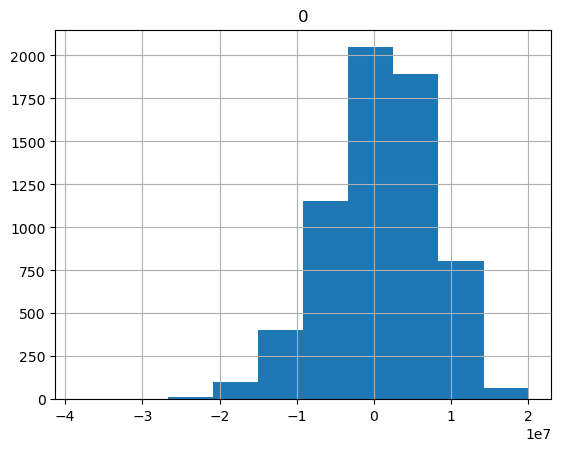

In [34]:
# Grafico del histograma de residuales para la base de prueba
df = pd.DataFrame(Resid)
df.hist()

In [35]:
from sklearn.metrics import r2_score
from sklearn import metrics

print('Coeficiente R cuadrado', r2_score(Y_test, Y_pred))

Coeficiente R cuadrado -305.47531148116343
